<a href="https://colab.research.google.com/github/Ashen-sam/rainfall-prediction-model/blob/main/samNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded_files = files.upload()

train_data = pd.read_csv("train.csv")

test_data = pd.read_csv("test.csv")

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
type(train_data)

pandas.core.frame.DataFrame

In [ ]:
train_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [ ]:
train_data.tail()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1
2189,2189,365,1013.8,21.2,19.1,18.0,18.0,89.0,88.0,1.0,70.0,48.0,1


In [ ]:
train_data.dtypes

,0
id,int64
day,int64
pressure,float64
maxtemp,float64
temparature,float64
mintemp,float64
dewpoint,float64
humidity,float64
cloud,float64
sunshine,float64


In [ ]:
train_data.isnull().sum() * 100 / train_data.shape[0]


,0
id,0.0
day,0.0
pressure,0.0
maxtemp,0.0
temparature,0.0
mintemp,0.0
dewpoint,0.0
humidity,0.0
cloud,0.0
sunshine,0.0


In [ ]:
test_data.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [ ]:
train_data.shape

(2190, 13)

In [ ]:
test_data.shape

(730, 12)

In [ ]:
test_data.isnull().sum() * 100 / test_data.shape[0]

,0
id,0.000000
day,0.000000
pressure,0.000000
maxtemp,0.000000
temparature,0.000000
mintemp,0.000000
dewpoint,0.000000
humidity,0.000000
cloud,0.000000
sunshine,0.000000


In [ ]:
wind_direction = train_data['winddirection'].median()
test_data['winddirection'] = test_data['winddirection'].fillna(wind_direction)

In [ ]:
test_data.isnull().sum() * 100 / test_data.shape[0]

,0
id,0.0
day,0.0
pressure,0.0
maxtemp,0.0
temparature,0.0
mintemp,0.0
dewpoint,0.0
humidity,0.0
cloud,0.0
sunshine,0.0


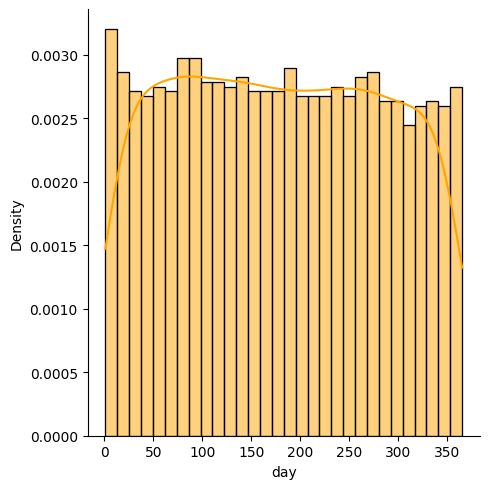

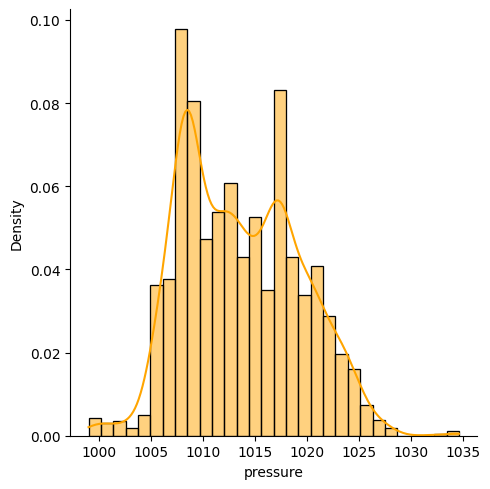

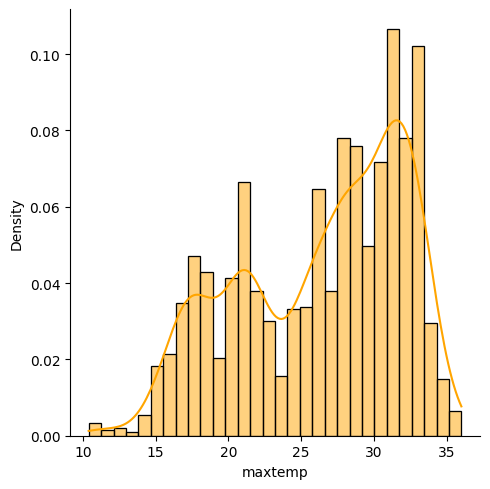

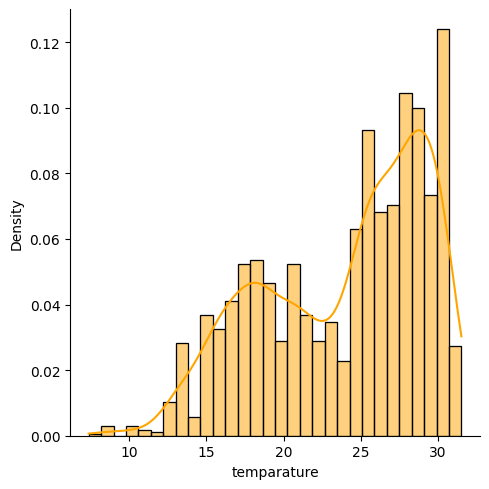

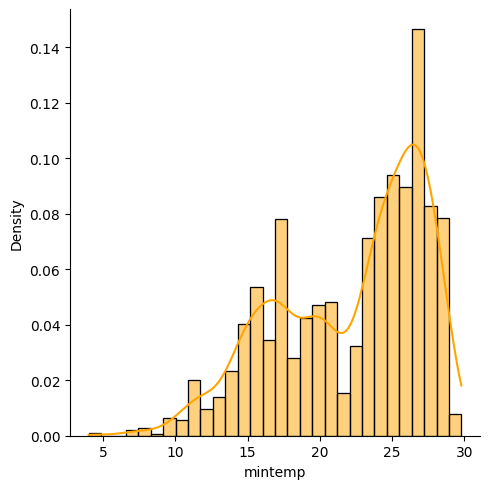

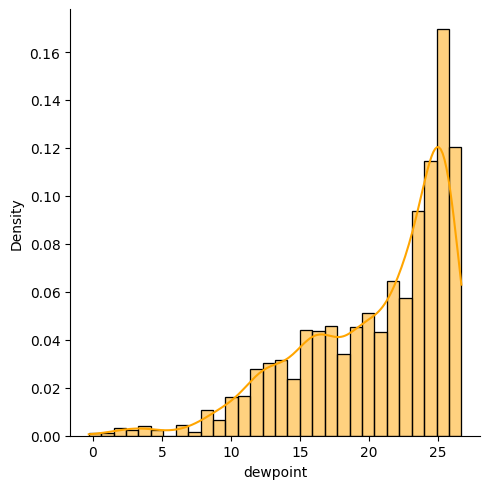

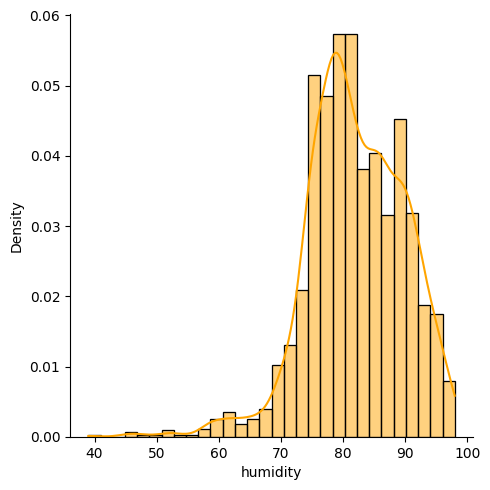

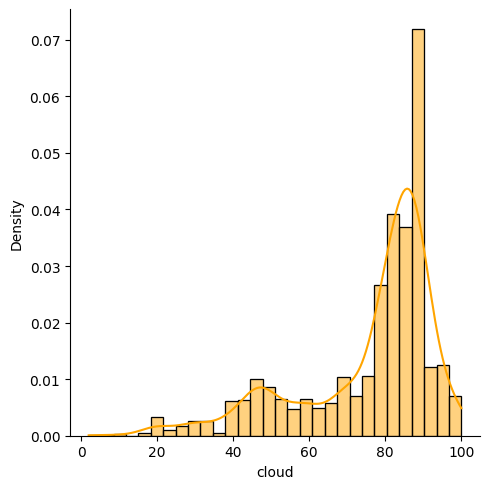

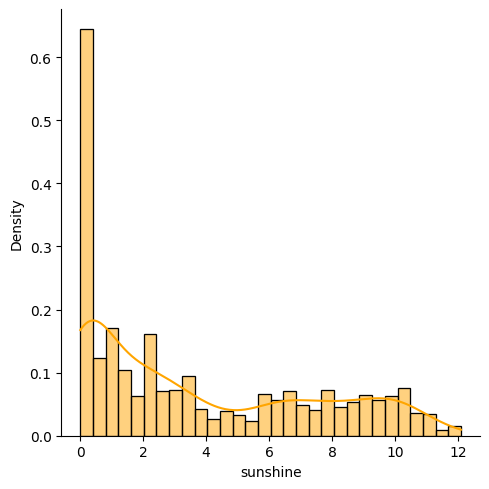

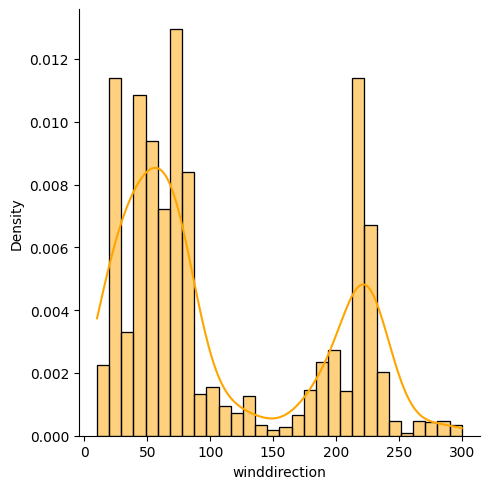

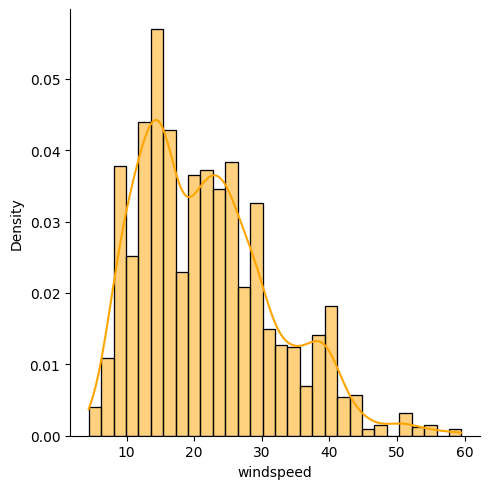

In [ ]:
import seaborn as sns
numerical_cols = [
    col for col in train_data.select_dtypes(include=['int64', 'float64']).columns
    if col not in ['id', 'rainfall']
]
for col in numerical_cols:
    sns.displot(train_data[col], kde=True, bins=30, stat="density", color='orange')

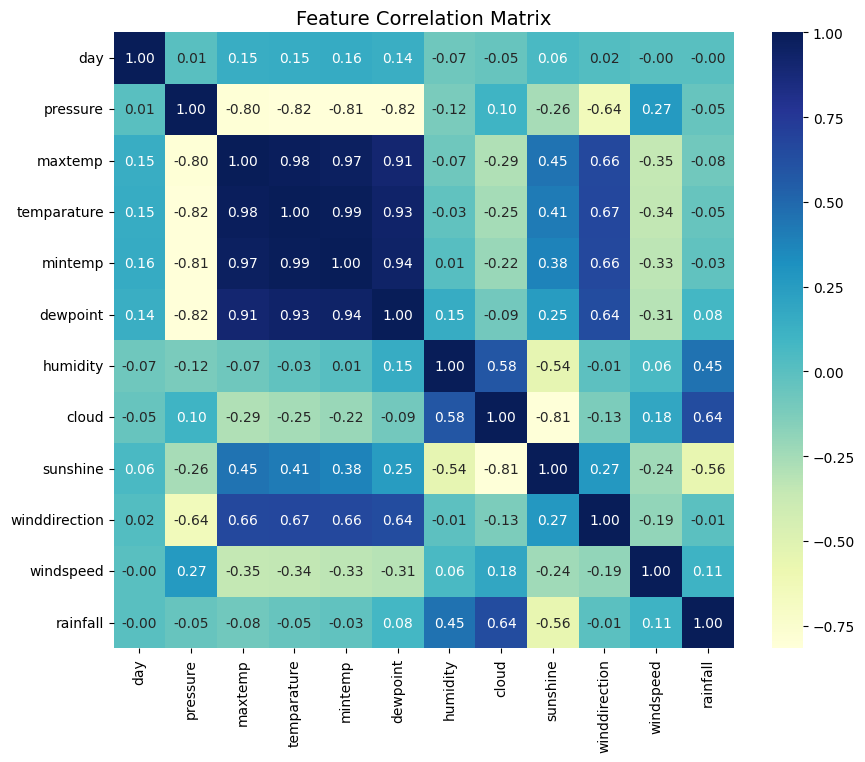

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

corr = train_data.drop(columns=['id']).corr()

sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt=".2f")

plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()

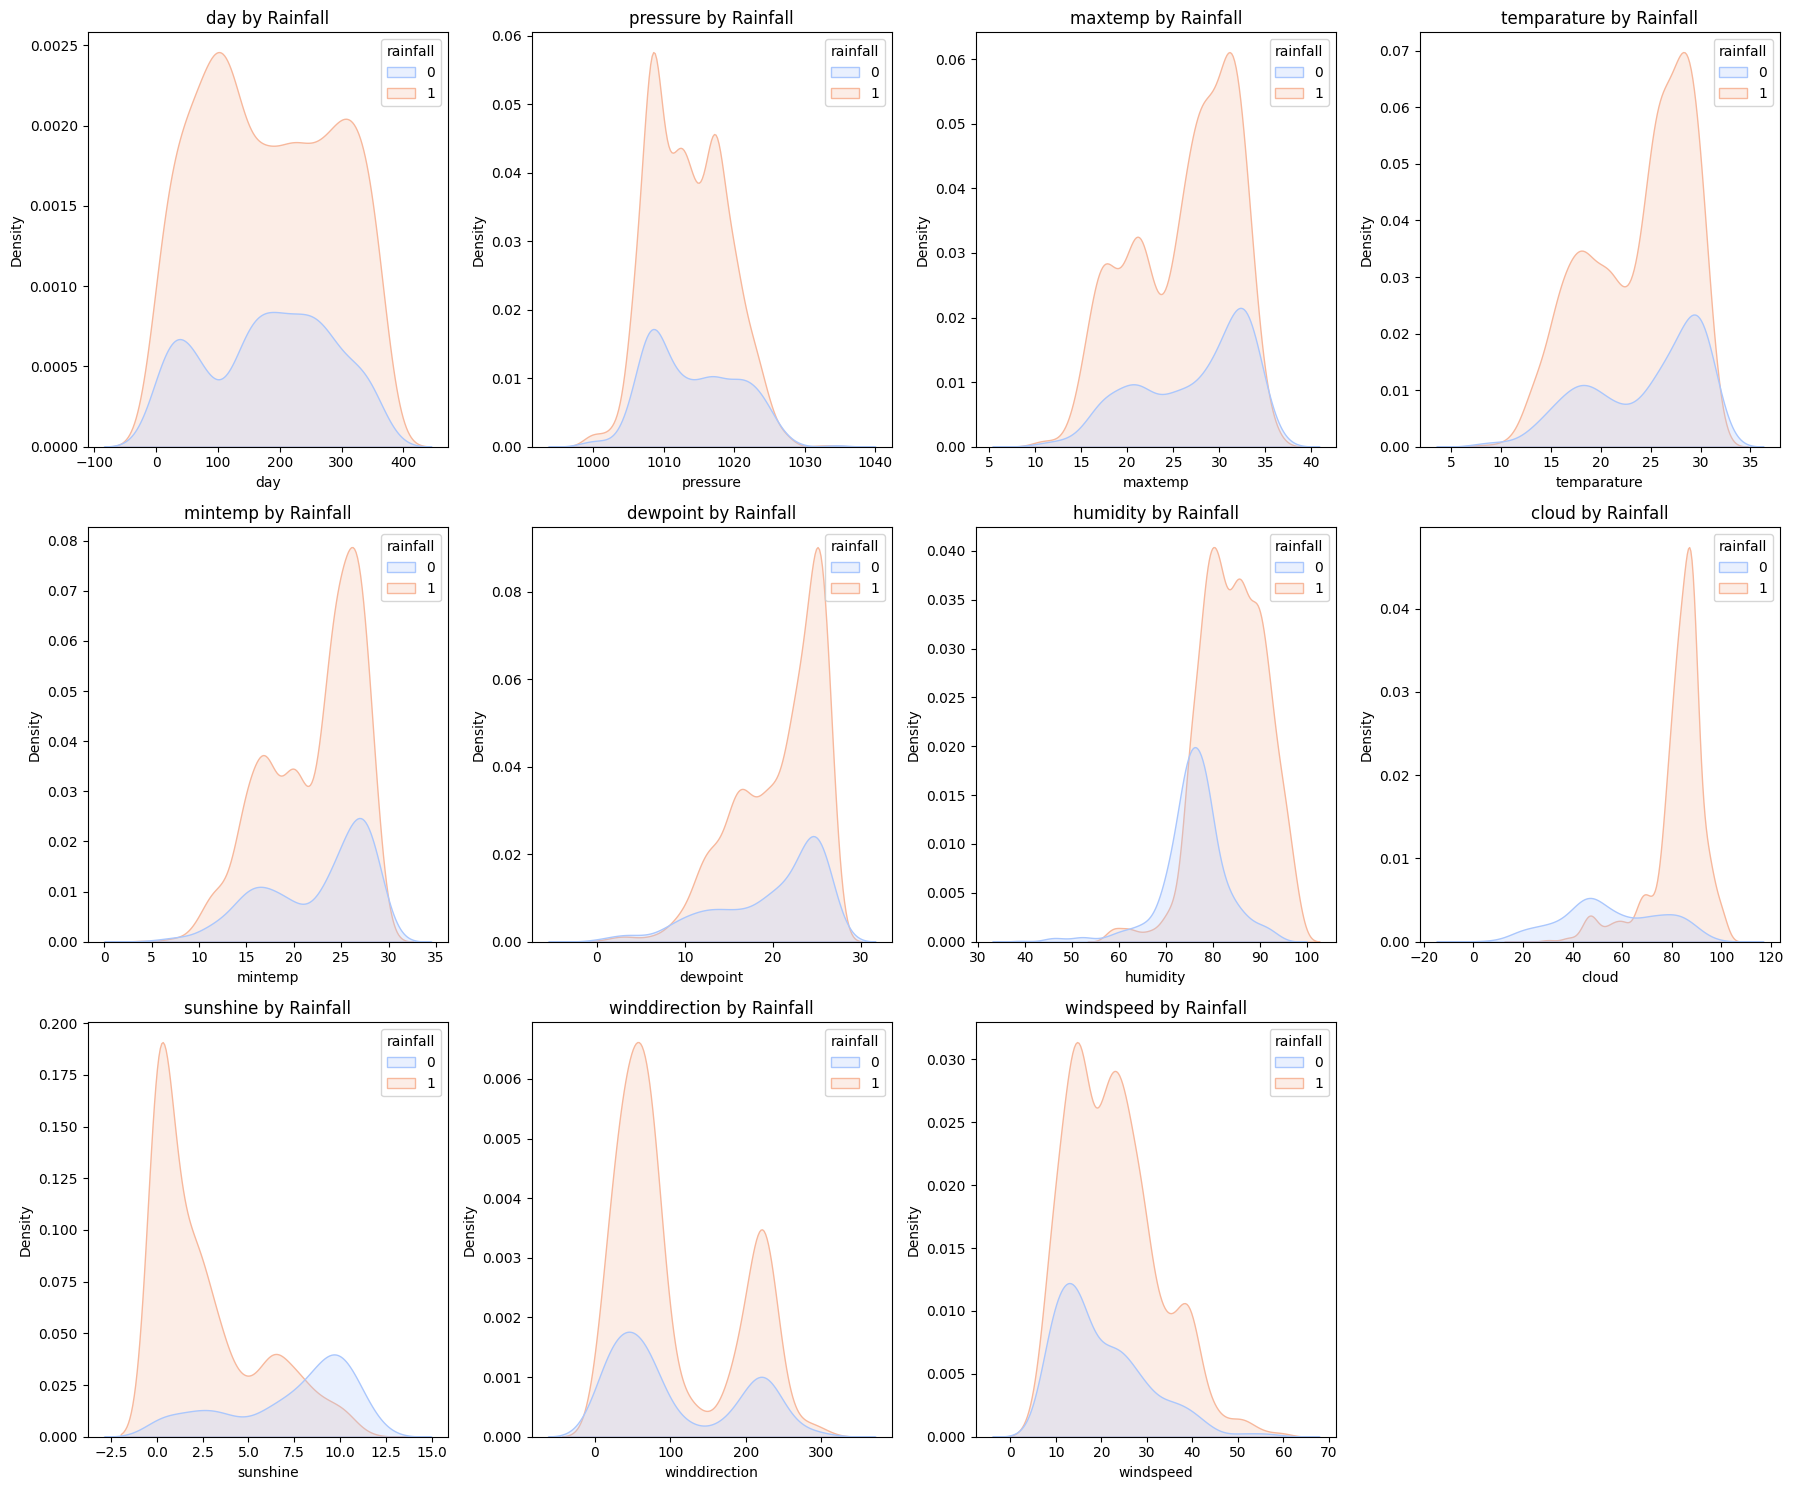

In [ ]:
# this is  features by rainfall using KDE plots
import seaborn as sns
import matplotlib.pyplot as plt
import math


cols_per_row = 4
total_plots = len(numerical_cols)
rows = math.ceil(total_plots / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(
        data=train_data,
        x=col,
        hue='rainfall',
        fill=True,
        palette='coolwarm',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by Rainfall', fontsize=12)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/tmp/ipython-input-1319164581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='rainfall', y=col, ax=axes[i], palette='Set2')
/tmp/ipython-input-1319164581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='rainfall', y=col, ax=axes[i], palette='Set2')
/tmp/ipython-input-1319164581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='rainfall', y=col, ax=axes[i], palette='Set2')
/tmp/ipython-input-1319164581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is depre

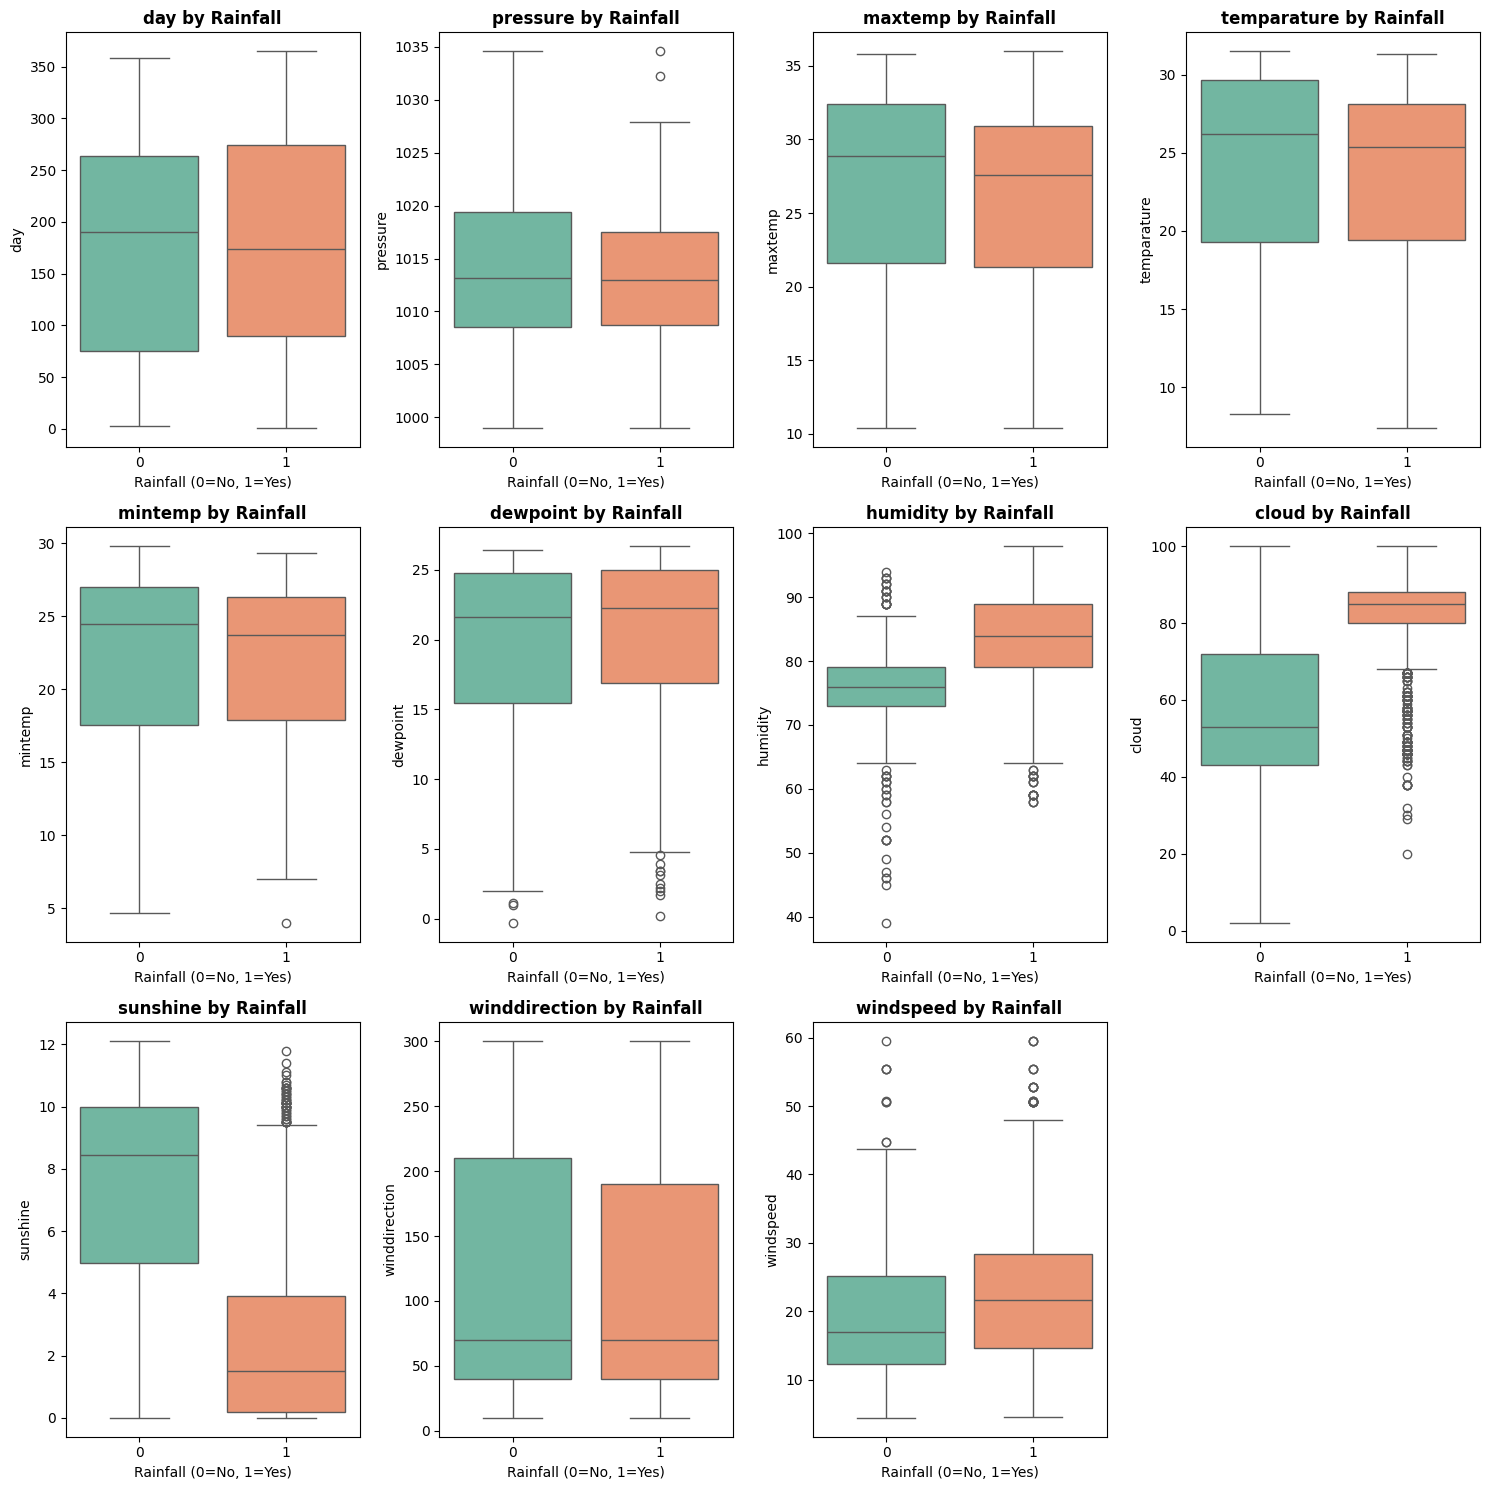

In [ ]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 5 * rows))
axes = axes.flatten() if rows > 1 else [axes] if rows == 1 else axes

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(data=train_data, x='rainfall', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} by Rainfall', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Rainfall (0=No, 1=Yes)', fontsize=10)

for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2530217125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rainfall', data=train_data, palette='coolwarm')


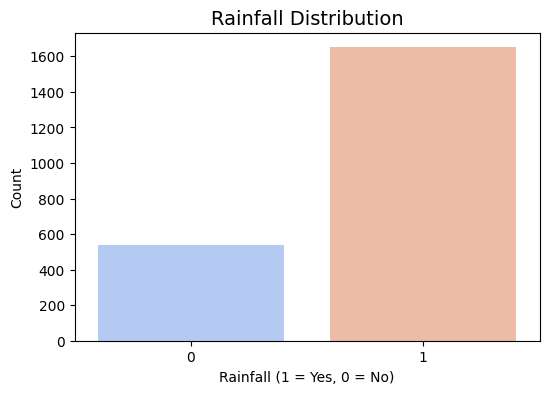

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='rainfall', data=train_data, palette='coolwarm')
plt.title("Rainfall Distribution", fontsize=14)
plt.xlabel("Rainfall (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = train_data.drop(['id', 'rainfall'], axis=1)
y = train_data['rainfall']

X_test = test_data.drop(['id'], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score



model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

model.fit(X_train, y_train)

y_valid_pred = model.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, y_valid_pred)

y_valid_pred_labels = (y_valid_pred >= 0.5).astype(int)
f1 = f1_score(y_valid, y_valid_pred_labels)

precision = precision_score(y_valid, y_valid_pred_labels)
recall = recall_score(y_valid, y_valid_pred_labels)


print("Validation ROC AUC:", roc_auc)
print("Validation F1 Score:", f1)

print("Precision:", precision)
print("Recall:", recall)

Validation ROC AUC: 0.8601591106662101
Validation F1 Score: 0.9014925373134328
Precision: 0.8603988603988604
Recall: 0.9467084639498433


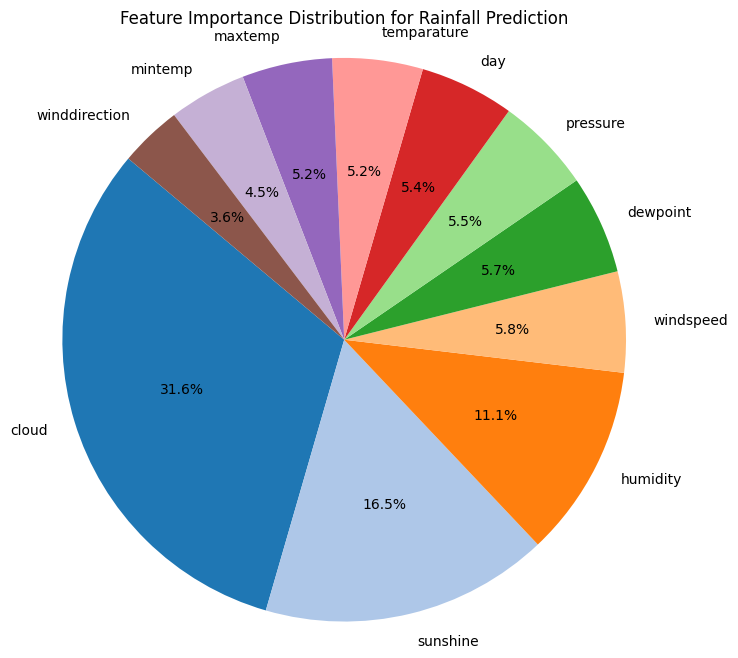

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(
    importance_df['Importance'],
    labels=importance_df['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.tab20.colors
)
plt.title('Feature Importance Distribution for Rainfall Prediction')
plt.axis('equal')
plt.show()

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.set_params(early_stopping_rounds=20)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

y_valid_proba = xgb_model.predict_proba(X_valid)[:, 1]
y_valid_pred = (y_valid_proba >= 0.5).astype(int)

roc_auc_xgb = roc_auc_score(y_valid, y_valid_proba)
f1 = f1_score(y_valid, y_valid_pred)
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)

print("ROC AUC Score:", roc_auc_xgb)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)


ROC AUC Score: 0.8630963357129685
F1 Score: 0.8770949720670391
Precision: 0.7909319899244333
Recall: 0.9843260188087775


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [01:37:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [ ]:
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

lgbm_model = LGBMClassifier(
    objective='binary',
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.3,
    reg_lambda=0.5,
    class_weight='balanced',
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=20),
        log_evaluation(0)
    ]
)

y_valid_proba = lgbm_model.predict_proba(X_valid)[:, 1]
y_valid_pred = (y_valid_proba >= 0.5).astype(int)

roc_auc_rf = roc_auc_score(y_valid, y_valid_proba)
f1 = f1_score(y_valid, y_valid_pred)
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)


print("ROC AUC:", roc_auc_rf)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

[LightGBM] [Info] Number of positive: 1331, number of negative: 421
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1553
[LightGBM] [Info] Number of data points in the train set: 1752, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True
)

nn_model.fit(X_train_scaled, y_train)

y_valid_proba = nn_model.predict_proba(X_valid_scaled)[:, 1]
y_valid_pred = (y_valid_proba >= 0.5).astype(int)

roc_auc_nn = roc_auc_score(y_valid, y_valid_proba)
f1 = f1_score(y_valid, y_valid_pred)
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)

print("Neural Net ROC AUC:", roc_auc_nn)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Neural Net ROC AUC: 0.8633070783172203
F1 Score: 0.8992481203007519
Precision: 0.8641618497109826
Recall: 0.9373040752351097


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

y_valid_proba = dt_model.predict_proba(X_valid)[:, 1]

y_valid_pred = (y_valid_proba >= 0.5).astype(int)

roc_auc_dt = roc_auc_score(y_valid, y_valid_proba)
f1 = f1_score(y_valid, y_valid_pred)
precision = precision_score(y_valid, y_valid_pred)
recall = recall_score(y_valid, y_valid_pred)

print("Decision Tree ROC AUC:", roc_auc_dt)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)


Decision Tree ROC AUC: 0.7649693106082558
F1 Score: 0.8830769230769231
Precision: 0.8670694864048338
Recall: 0.8996865203761756


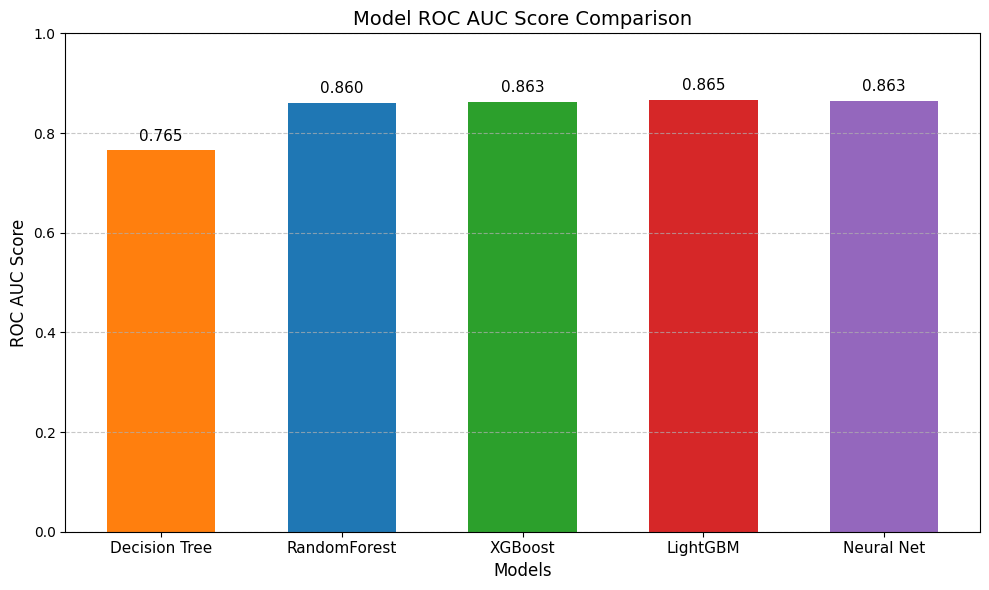

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ['Decision Tree', 'RandomForest', 'XGBoost', 'LightGBM', 'Neural Net']

roc_auc_scores = [
    roc_auc_dt,
    roc_auc,
    roc_auc_xgb,
    roc_auc_rf,
    roc_auc_nn
]

x = np.arange(len(models))

plt.figure(figsize=(10, 6))

colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd']

plt.bar(x, roc_auc_scores, color=colors, width=0.6)

plt.xlabel('Models', fontsize=12)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.title('Model ROC AUC Score Comparison', fontsize=14)
plt.xticks(x, models, fontsize=11)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, score in enumerate(roc_auc_scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated ROC AUC:", grid_search.best_score_)

best_dt = grid_search.best_estimator_


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validated ROC AUC: 0.8662362187137816


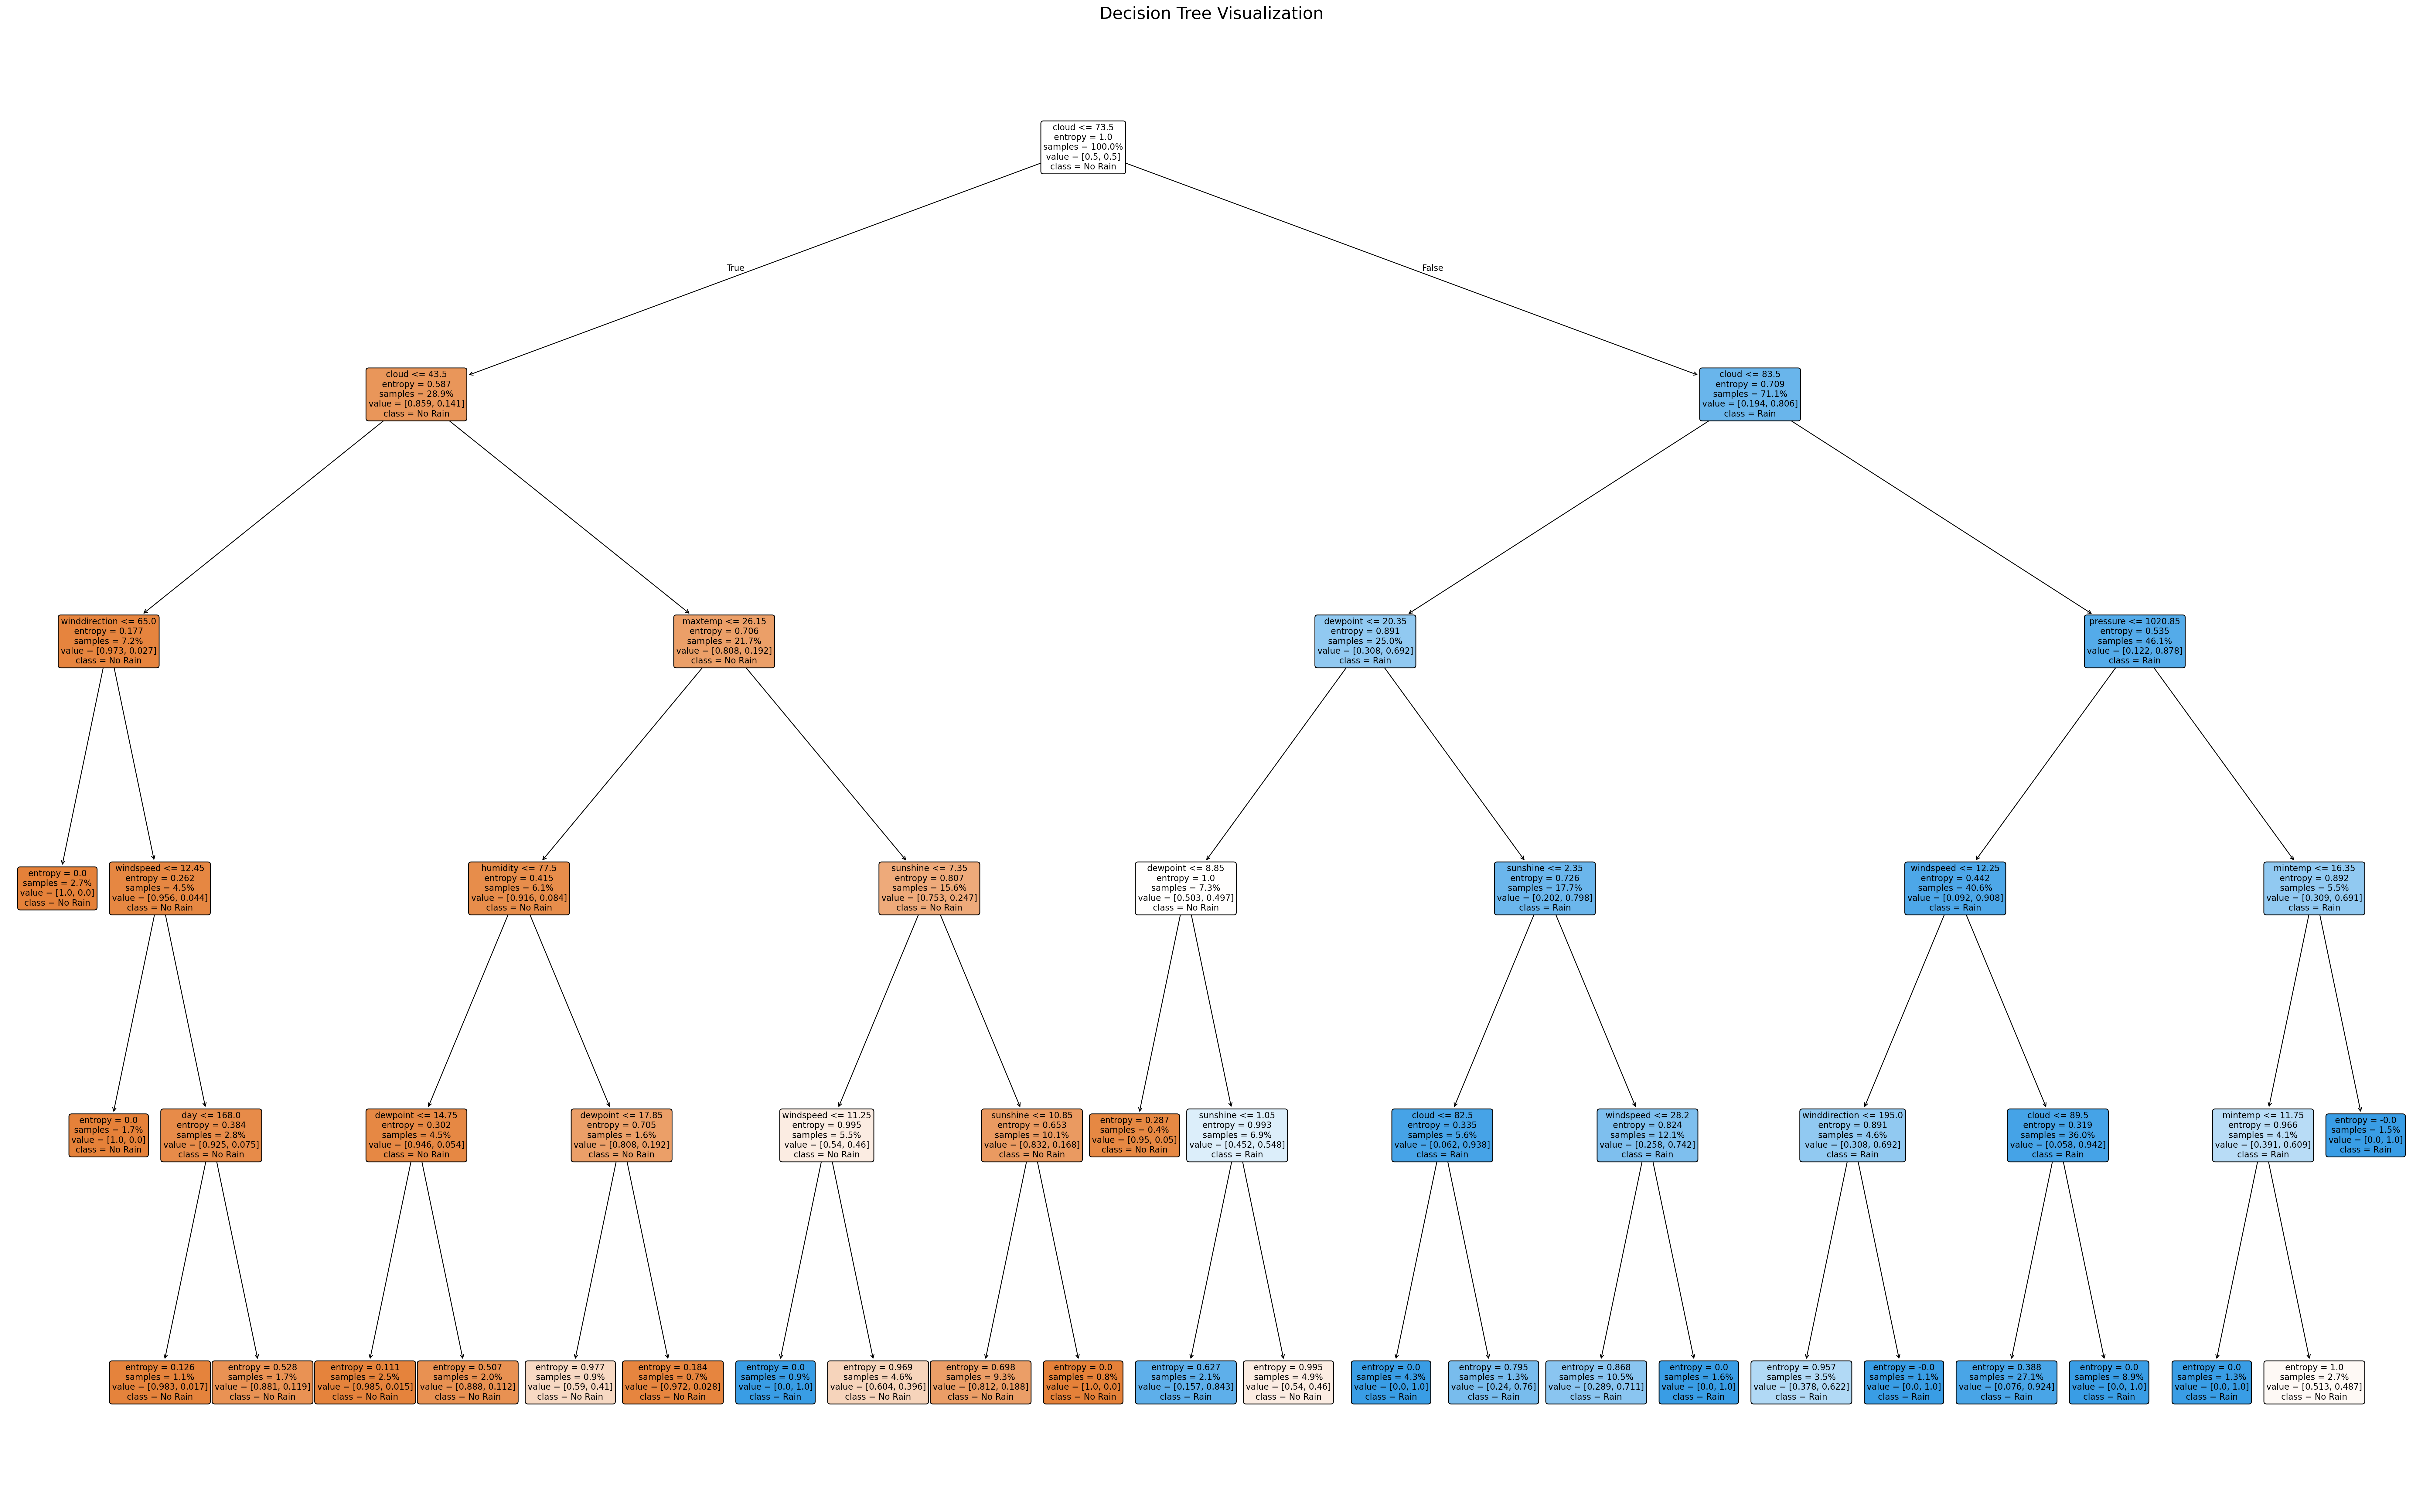

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(40, 25), dpi=200)

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=['No Rain', 'Rain'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True
)

plt.title("Decision Tree Visualization", fontsize=20)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF ROC AUC:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_



Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best RF ROC AUC: 0.8971159175280599


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

xgb_grid = GridSearchCV(
    xgb_clf,
    param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB ROC AUC:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_


Fitting 3 folds for each of 243 candidates, totalling 729 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:08:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.7}
Best XGB ROC AUC: 0.9010235127406493


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.1],
    'max_depth': [8],
    'num_leaves': [31, 64],
    'subsample': [0.9],
    'colsample_bytree': [0.9],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1]
}

lgbm_clf = LGBMClassifier(objective='binary', class_weight='balanced', random_state=42)

lgbm_grid = GridSearchCV(
    lgbm_clf,
    param_grid_lgbm,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

lgbm_grid.fit(X_train, y_train)

print("Best LGBM params:", lgbm_grid.best_params_)
print("Best LGBM ROC AUC:", lgbm_grid.best_score_)

best_lgbm = lgbm_grid.best_estimator_


Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Info] Number of positive: 1331, number of negative: 421
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1553
[LightGBM] [Info] Number of data points in the train set: 1752, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=300, random_state=42, early_stopping=True))
])

param_grid_nn = {
    'mlp__hidden_layer_sizes': [(64,), (128, 64), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01],
}

nn_grid = GridSearchCV(
    pipeline,
    param_grid_nn,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

nn_grid.fit(X_train, y_train)

print("Best NN params:", nn_grid.best_params_)
print("Best NN ROC AUC:", nn_grid.best_score_)

best_nn = nn_grid.best_estimator_


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best NN params: {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__learning_rate_init': 0.01}
Best NN ROC AUC: 0.8995272359538005


In [ ]:
# After tuning each model, you get:
best_dt = grid_search.best_estimator_
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
best_lgbm = lgbm_grid.best_estimator_
best_nn = nn_grid.best_estimator_


roc_auc_dt = grid_search.best_score_
roc_auc_rf = rf_grid.best_score_
roc_auc_xgb = xgb_grid.best_score_
roc_auc_lgbm = lgbm_grid.best_score_
roc_auc_nn = nn_grid.best_score_


model_scores = {
    'Decision Tree': (best_dt, roc_auc_dt),
    'Random Forest': (best_rf, roc_auc_rf),
    'XGBoost': (best_xgb, roc_auc_xgb),
    'LightGBM': (best_lgbm, roc_auc_lgbm),
    'Neural Net': (best_nn, roc_auc_nn),
}

# Find the model with the best ROC AUC
best_model_name = max(model_scores, key=lambda k: model_scores[k][1])
best_model, best_score = model_scores[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best ROC AUC: {best_score:.4f}")



Best model: XGBoost
Best ROC AUC: 0.9010


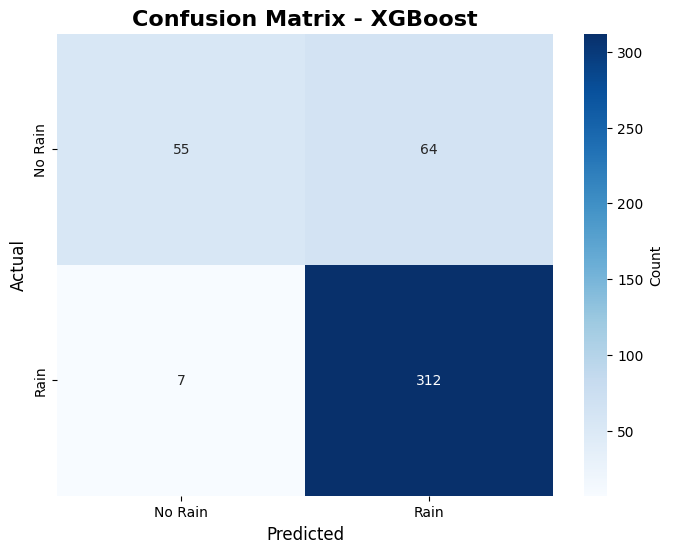

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_valid_pred_labels = (best_model.predict_proba(X_valid)[:, 1] >= 0.5).astype(int)


cm = confusion_matrix(y_valid, y_valid_pred_labels)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In [ ]:
test_predictions = best_model.predict_proba(X_test)[:, 1]

In [ ]:
submission_df = pd.DataFrame({
    'id': test_data['id'],
    'rainfall': test_predictions
})
submission_df.to_csv('rainfall.csv', index=False)
files.download('rainfall.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pickle

with open('my_best.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("My Best model saved")
files.download('my_best.pkl')

My Best model saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

# Ask user for inputs
day = float(input("Day (1-365): "))
pressure = float(input("Pressure: "))
maxtemp = float(input("Max Temperature: "))
temparature = float(input("Temperature: "))
mintemp = float(input("Min Temperature: "))
dewpoint = float(input("Dew Point: "))
humidity = float(input("Humidity: "))
cloud = float(input("Cloud: "))
sunshine = float(input("Sunshine: "))
winddirection = float(input("Wind Direction: "))
windspeed = float(input("Wind Speed: "))

# Arrange inputs in the same order as training features
user_input = np.array([[day, pressure, maxtemp, temparature, mintemp,
                        dewpoint, humidity, cloud, sunshine,
                        winddirection, windspeed]])

# Predict with the best model (already trained XGBoost)
proba = best_model.predict_proba(user_input)[0][1]
prediction = int(proba >= 0.5)

# Show results
print("\n=== Rainfall Prediction ===")
print(f"Rain Probability: {proba:.2f}")
print("Predicted:", " Rain" if prediction == 1 else " No Rain")